---
title: "TECH CHALLENGE FASE 1"
author: "Júlia Borges Santos"
date: last-modified
format:
  html:
    theme: cosmo
execute:
  echo: false
  warning: false
---

### 1. Entendimento do negócio:  nessa primeira etapa, queremos exercitar o seu pensamento analítico, não código. Nos traga a resposta para as seguintes perguntas de negócio: 

● Qual problema de negócio está sendo resolvido? 

● Por que o NPS é importante para um e-commerce? 

● Quais áreas poderiam se beneficiar desses insights? Exemplos: 
logística, atendimento, pricing, produto etc.

Como o NPS impacta: 

● Recompra; 

● Boca a boca; 

● Market share em e-commerce. 

● Quais indicadores de mercado poderiam complementar essa análise? 

[R: De acordo com o cenário apresentado, o problema a ser resolvido é entender o comportamento do cliente de forma preditiva; não deixar para entender no final da jornada o quê o cliente sente, mas sim antes e durante a ação de compra.]{style="color: red;"}

[O NPS figura como um dos principais indicadores de qualidade de um produto justamente por ser prático de ser respondido (pensando no ponto de vista do cliente), ao mesmo tempo que é facilmente interpretado (pensando no ponto de vista do gestor), e através dele a empresa é capaz de tomar medidas no caminho que o cliente trilha até chegar a compra do produto de fato.]{style="color: red;"}

[Sem sombra de dúvidas, as principais áreas que poderiam se beneficiar são a logística, atendimento e produto; a logística se beneficiaria dos insights baseados no NPS no sentido de entender quais são as principais regiões que consomem aquele produto, e como reduzir ao máximo o lead time desde a compra até a entrega para o consumidor; já o atendimento se beneficiaria pois as ações que tangem ao cuidado e tratamento com o cliente seriam mais direcionadas ao que os clientes aprovam e reprovam na hora de se relacionar com a marca; além disso, a experiência do usuário no site é diretamente afetada pela percepção de valor captada pelo NPS. Aspectos como facilidade de navegação, retenção e a conclusão da jornada de compra dependem de quão satisfeito o cliente está ao interagir com o ecossistema da loja, que é a principal vitrine e ponto de conversão.]{style="color: red;"}

[O NPS é um termômetro vital para o e-commerce porque impacta o faturamento de forma direta. Clientes promotores compram mais vezes (recompra) e trazem novos usuários de forma orgânica (boca a boca) a medida que indicam a marca para pessoas com padrões de consumo semelhantes, o que reduz o custo de marketing e fortalece a marca frente à concorrência, protegendo seu market share.]{style="color: red;"}

[Para uma visão completa, não basta olhar apenas para a lealdade; é preciso cruzar esses dados com indicadores como o Churn Rate (para ver quem está saindo), o CAC (custo para atrair novos clientes) e o LTV (valor total que o cliente deixa na empresa). Essa combinação mostra se a satisfação está, de fato, se transformando em lucro sustentável.]{style="color: red;"}

---------------------

### 2. Definição da Target: qual é o alvo desse problema de negócio? Nessa segunda etapa queremos uma avaliação de entendimento conceitual, não técnico. 

● Qual variável representa a satisfação do cliente? 

● Por que ela foi escolhida? 

● Em que momento da jornada essa informação é coletada? 

● Existe algum risco de usar essa variável de forma inadequada? 

[R: A variável alvo é justamente o nps_score.]{style="color: red;"}

[Ela é coletada somente ao final da jornada de compra do consumidor.]{style="color: red;"}

[O risco associado a essa varíavel pode ser resumido no conceito de **data leakage**, ou vazamento de dados, que no caso em questão é sobre só termos a variável alvo no final do processo, sendo que o objetivo é prever essa variável antes do encerramento da jornada. Dessa forma, o modelo teria uma performance artificial nos testes e falhará nos dados em produção, pois ele tentará prever o futuro usando dados do próprio futuro.]{style="color: red;"}

---------------------

### 3. Análise Exploratória dos Dados (EDA): realize uma análise exploratória com foco em negócio, não só estatística. Responda: 

● Quais fatores parecem mais críticos para a satisfação? 

● O que mais gera detratores? 

● Existe algum “ponto de ruptura” na experiência do cliente? 

● Que tipo de cliente tende a ter NPS mais alto ou mais baixo? 

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

df_original = pd.read_csv('../data/raw/desafio_nps_fase_1.csv')
df = df_original.drop(columns='customer_id')

[R: Observando a matriz de correlação entre as variáveis da base de dados fornecida, podemos concluir que os principais fatores mais críticos para a satisfação do cliente são, ordenados de forma decrescente sobre o valor que tem mais força para impactar no nps_score :]{style="color: red;"}

[● delivery_delay_days (quantidade de dias de atraso na entrega; corr=-0.60).]{style="color: red;"}

[● complaints_count (número de reclamações registradas pelo cliente; corr=-0.50).]{style="color: red;"}

[● customer_service_contacts (número de contatos do cliente com o atendimento; corr=-0.35).]{style="color: red;"}


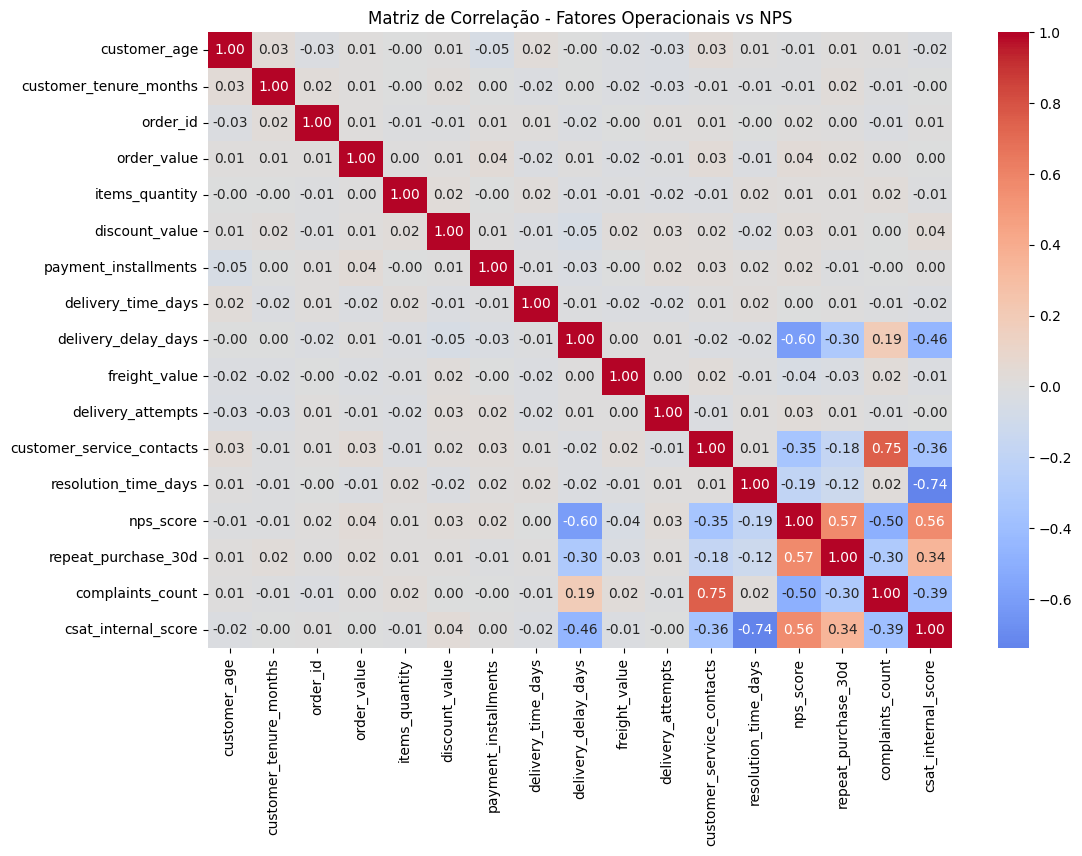

In [4]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title('Matriz de Correlação - Fatores Operacionais vs NPS')
plt.show()


[O principal motivo que mais gera detratores é o tempo de atrasado da entrega (corr=-0.60), e isso releva o quão importante é o cumprimento dos prazos nesse cenário.]{style="color: red;"}

[Além disso, a variável **complaints_count** tem forte relação direta com a variável **customer_service_contacts** (número de contatos do cliente com o atendimento), isso na prática sugere que o principal motivo pelos quais surgem os contatos geralmente está relacionada a dúvidas ou reclamações, e a quantidade de reclamações está associada ao nps de forma inversamente proporcional, ou seja, quanto maior o número de reclamações, menor é a nota de nps.]{style="color: red;"}

[Para entender melhor o ponto de ruptura, foi destrinchado a variável que apresenta maior impacto negativo no nps: o **tempo de atraso na entrega**:]{style="color: red;"}

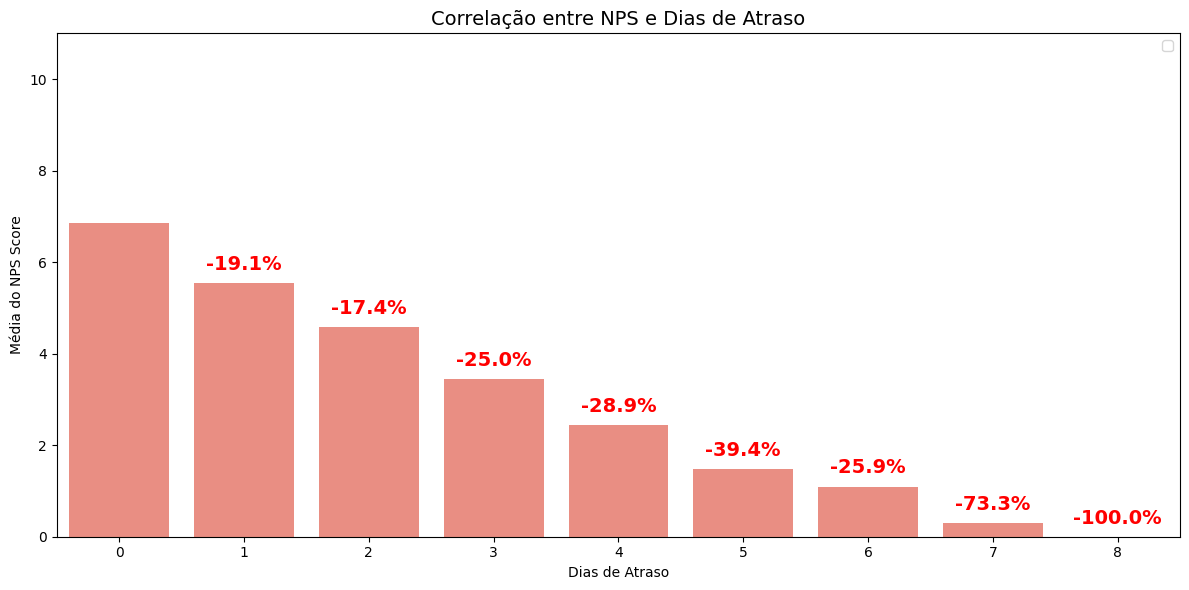

In [5]:
df_agrupado = df.groupby('delivery_delay_days')['nps_score'].mean().reset_index()
df_agrupado['pct_change'] = df_agrupado['nps_score'].pct_change() * 100

plt.figure(figsize=(12, 6))
plot = sns.barplot(x='delivery_delay_days', y='nps_score', data=df_agrupado, color='salmon')

for i in range(1, len(df_agrupado)):
    queda = df_agrupado.loc[i, 'pct_change']
    x = i
    y = df_agrupado.loc[i, 'nps_score']
    if queda < 0:
        plt.text(x, y + 0.2, f'{queda:.1f}%', ha='center', va='bottom', 
                 fontsize=14, fontweight='bold', color='red')
        
plt.title('Correlação entre NPS e Dias de Atraso', fontsize=14)
plt.xlabel('Dias de Atraso')
plt.ylabel('Média do NPS Score')
plt.ylim(0, 11) 
plt.legend()
plt.grid(False)
plt.tight_layout()

[O gráfico em questão nos revela que, a medida que o tempo de atraso aumenta a média do NPS diminui, e essa queda é ainda mais acentuada entre os dias 4 e 5 de *delay*, onde a média da nota sofre uma redução de 39.4%. Ou seja, até o 4º dia o cliente ainda tem certa tolerância, porém, quando o atraso entra no 5º dia, o cliente já está insatisfeito com a empresa, e se torna mais difícil tentar reverter a situação.]{style="color: red;"}

[Para verificar o tipo de cliente que tende a ter NPS mais alto ou mais baixo, foi gerado os seguintes gráficos com as principais variáveis relacionadas ao aumento e diminuição do target: ]{style="color: red;"}

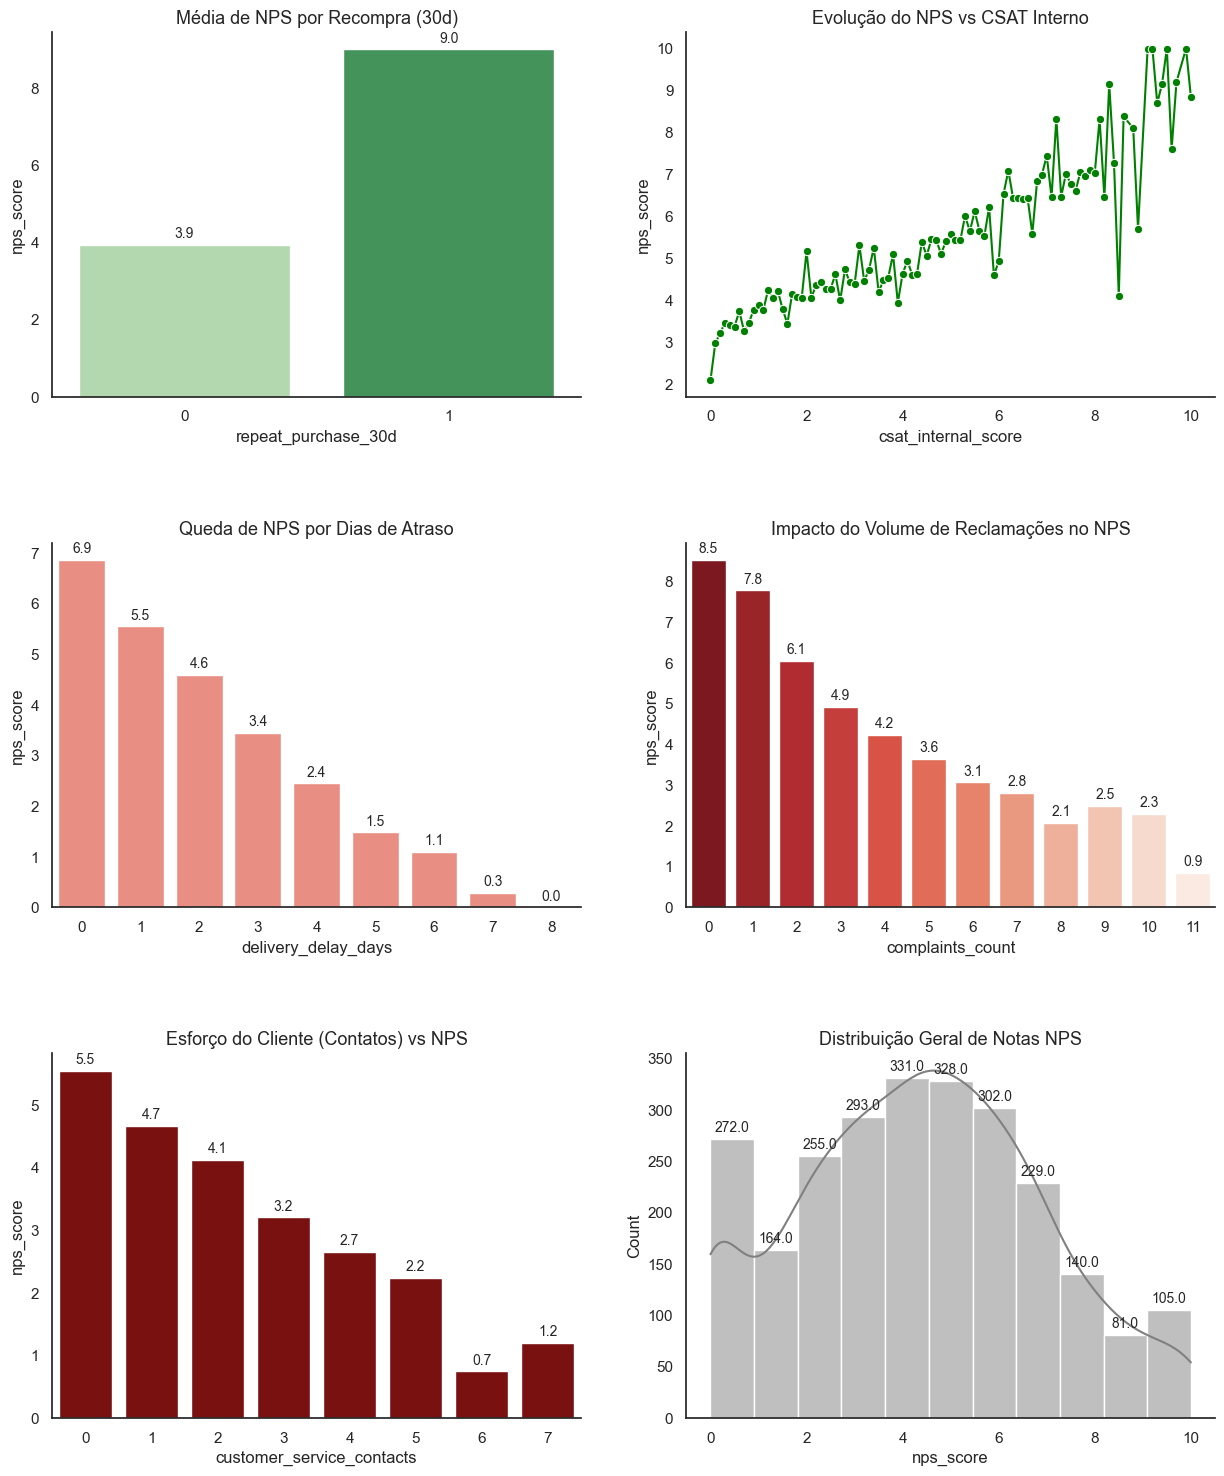

In [ ]:
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4)

# 1. Recompra em 30 dias 
sns.barplot(ax=axes[0, 0], data=df, x='repeat_purchase_30d', y='nps_score', palette='Greens', errorbar=None)
axes[0, 0].set_title('Média de NPS por Recompra (30d)', fontsize=13)

# 2. CSAT Interno
sns.lineplot(ax=axes[0, 1], data=df, x='csat_internal_score', y='nps_score', color='green', marker='o', errorbar=None)
axes[0, 1].set_title('Evolução do NPS vs CSAT Interno', fontsize=13)

# 3. Dias de Atraso 
sns.barplot(ax=axes[1, 0], data=df, x='delivery_delay_days', y='nps_score', color='salmon', errorbar=None)
axes[1, 0].set_title('Queda de NPS por Dias de Atraso', fontsize=13)

# 4. Quantidade de Reclamações 
sns.barplot(ax=axes[1, 1], data=df, x='complaints_count', y='nps_score', palette='Reds_r', errorbar=None)
axes[1, 1].set_title('Impacto do Volume de Reclamações no NPS', fontsize=13)

# 5. Contatos com Suporte 
sns.barplot(ax=axes[2, 0], data=df, x='customer_service_contacts', y='nps_score', color='darkred', errorbar=None)
axes[2, 0].set_title('Esforço do Cliente (Contatos) vs NPS', fontsize=13)

# 6. Histograma Geral
sns.histplot(ax=axes[2, 1], data=df, x='nps_score', bins=11, kde=True, color='gray')
axes[2, 1].set_title('Distribuição Geral de Notas NPS', fontsize=13)

# Adicionando rótulos em todos os eixos que possuem barras
for ax in axes.flat:
    if len(ax.containers) > 0:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=3, fontsize=10)

sns.despine()
plt.show()

Principais considerações:

O perfil de cliente com NPS mais alto:

[● Apresenta alta taxa de fidelização (recompra em 30 dias);]{style="color: red;"}

[● Valoriza a resolução imediata no primeiro contato.]{style="color: red;"}

O perfil de cliente com NPS mais baixo:

[● Possui baixa tolerância a atrasos logísticos (queda drástica a cada dia de atraso);]{style="color: red;"}

[● Reage negativamente à necessidade de múltiplos contatos com o suporte (reincidência).]{style="color: red;"}